# 📚 Import Required Libraries

This notebook imports all the libraries required for data processing, visualization, semantic text embedding, model training, evaluation, and data loading. Each library is used for a specific task in the resume matching pipeline.

In [1]:
!nvidia-smi

Thu Jul 30 08:08:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import torch
print(torch.cuda.device_count())              # 1 aana chahiye
print(torch.cuda.get_device_name(0)) 

1
Tesla T4


In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [4]:
import torch
print(torch.cuda.device_count()) 

1


In [5]:
# ============================
# Data Manipulation
# ============================
import pandas as pd          # Work with tables (DataFrames).
import numpy as np           # Numerical operations and arrays.

# ============================
# Data Visualization
# ============================
import matplotlib.pyplot as plt   # Create charts and plots.
import seaborn as sns             # Statistical data visualization.

# ============================
# Sentence Transformers
# ============================
from sentence_transformers import (
    SentenceTransformer,          # Generate text embeddings.
    InputExample,                 # Create training examples.
    losses,                       # Training loss functions.
    evaluation                    # Evaluate Sentence Transformer models.
)

# ============================
# Similarity
# ============================
from sklearn.metrics.pairwise import cosine_similarity   # Compute cosine similarity.

# ============================
# Dataset Splitting
# ============================
from sklearn.model_selection import train_test_split     # Split dataset into train and test sets.

# ============================
# Evaluation Metrics
# ============================
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)   # Evaluate prediction performance.

# ============================
# Data Loader
# ============================
from torch.utils.data import DataLoader    # Load data in batches during training.

# ============================
# Warnings
# ============================
import warnings
warnings.filterwarnings("ignore")          # Hide unnecessary warnings.

# ============================
# Visualization Settings
# ============================
sns.set_style("whitegrid")                 # Apply a clean plot style.
plt.rcParams["figure.figsize"] = (12, 6)   # Set the default figure size.

# Confirm successful import.
print("Libraries imported successfully!")

Libraries imported successfully!


/tmp/ipykernel_608/2491674769.py:16: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import (
/tmp/ipykernel_608/2491674769.py:16: DeprecationWarning: Importing from 'sentence_transformers.evaluation' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.evaluation' instead.
  from sentence_transformers import (


# 📂 Load and Inspect the Dataset

In this step, we load the resume-job matching dataset into a Pandas DataFrame and perform an initial inspection. We check the dataset size, examine the distribution of match labels, verify the range of match scores, and preview the first three records. This helps ensure that the dataset has been loaded correctly and is ready for preprocessing and model training.

In [6]:
# Load the dataset from a CSV file.
df = pd.read_csv("/kaggle/input/datasets/khemchandmehra/cleaned-resumejd-pairs/cleaned_resumeJD_pairs.csv")

# Display the number of rows and columns.
print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Display the distribution of match labels.
print("\nLabel Distribution:")
print(df["match_label"].value_counts())

# Display the minimum and maximum match scores.
print(
    f"\nMatch Score Range: "
    f"{df['match_score'].min():.2f} - {df['match_score'].max():.2f}"
)

# Display the first three rows of the dataset.
df.head(3)

Dataset Shape: 3,221 rows × 7 columns

Label Distribution:
match_label
high      1261
medium    1000
low        960
Name: count, dtype: int64

Match Score Range: 0.19 - 0.90


,resume_text,job_description,match_score,match_label,match_label_lower,resume_len,jd_len
0,Professional SummaryMore than 6 years experien...,RESPONSIBILITIES ACCOUNTS PAYABLE (60 ) Proce...,0.22,low,low,862,340
1,SummaryTo obtain a challenging position in the...,Job Title Software DeveloperLocation Pittsbur...,0.24,low,low,795,195
2,Summary5 years of professional experience in M...,Lead Software Developer New York City - Hybri...,0.22,low,low,708,199


# ✂️ Split the Dataset into Train, Validation, and Test Sets

In this step, we split the dataset into three parts for model development. The training set is used to train the model, the validation set is used to monitor performance and tune hyperparameters, and the test set is reserved for final evaluation. Stratified sampling is applied to preserve the same distribution of match labels across all splits.

In [7]:
# Split the dataset into training (70%) and temporary (30%) sets.
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["match_label"]
)

# Split the temporary set into validation (15%) and test (15%) sets.
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["match_label"]
)

# Display the size of each dataset.
print(f"Training Samples   : {len(train_df)}")
print(f"Validation Samples : {len(val_df)}")
print(f"Test Samples       : {len(test_df)}")

print()

# Verify that each split contains all match labels.
for name, split in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(f"{name} Label Distribution:")
    print(split["match_label"].value_counts())
    print("-" * 40)

Training Samples   : 2254
Validation Samples : 483
Test Samples       : 484

Train Label Distribution:
match_label
high      882
medium    700
low       672
Name: count, dtype: int64
----------------------------------------
Validation Label Distribution:
match_label
high      189
medium    150
low       144
Name: count, dtype: int64
----------------------------------------
Test Label Distribution:
match_label
high      190
medium    150
low       144
Name: count, dtype: int64
----------------------------------------


# 📝 Convert Data into Sentence Transformer Input Examples

In this step, we convert the training and validation datasets into the format required by the Sentence Transformer library. Each sample is stored as an **InputExample**, containing a resume, a job description, and a match score between **0 and 1**. These InputExample objects will be used later to create DataLoaders and fine-tune the Sentence Transformer model.

In [8]:
# Convert the training dataset into InputExample objects.
train_examples = [
    InputExample(
        texts=[row["resume_text"], row["job_description"]],
        label=float(row["match_score"])
    )
    for _, row in train_df.iterrows()
]

# Convert the validation dataset into InputExample objects.
val_examples = [
    InputExample(
        texts=[row["resume_text"], row["job_description"]],
        label=float(row["match_score"])
    )
    for _, row in val_df.iterrows()
]

# Display the number of training and validation examples.
print(f"Training Examples   : {len(train_examples)}")
print(f"Validation Examples : {len(val_examples)}")

# Display the first training example.
print("\nSample Input Example")
print("-" * 50)

print(f"Resume Text        : {train_examples[0].texts[0]}")
print(f"Job Description    : {train_examples[0].texts[1]}")
print(f"Match Score (Label): {train_examples[0].label}")

Training Examples   : 2254
Validation Examples : 483

Sample Input Example
--------------------------------------------------
Resume Text        : Professional SummaryFinancial Accountant with 3 years of experience. Possess a B.S. in Accounting and Advanced Accounting MIS certificates. Looking to leverage my knowledge and experience into a role as an Accountant. SkillsFinancial reporting specialistFiscal budgeting knowledgeAccounting operations professionalTax accounting specializationSPSS STATA SAS software proficientInvoice coding familiarityFinancial modeling capabilityCash flow analysisBudget analysisData trending knowledgeAccount reconciliation specialistAccounting softwareMS Office SuiteSelf-motivated professionalStrong communication skillsSuperior attention to detailWorking with shifting prioritiesManaging multiple projects simultaneouslyWeb application implementationTest-driven programmingMicrosoft SharePointIdentifying best practicesMicrosoft Visio Work HistoryFinancial Accoun

# 🤖 Load the Pre-trained BERT Model

In this step, we load the pre-trained **all-mpnet-base-v2** Sentence Transformer model. This model has already been trained on large-scale text data and can generate high-quality semantic embeddings for sentences. It will be fine-tuned later on the resume-job matching dataset.

In [9]:
# Display a loading message.
print("Loading pre-trained BERT model...")

# Load the pre-trained Sentence Transformer model.
base_model = SentenceTransformer("all-mpnet-base-v2")

# Confirm that the model was loaded successfully.
print("✅ Model loaded successfully!")

Loading pre-trained BERT model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded successfully!


# 📊 Evaluate the Base Model on the Test Set

Before fine-tuning, we evaluate the pre-trained Sentence Transformer on the test set to establish a **baseline performance**. For each resume-job description pair, the model generates embeddings, computes their cosine similarity, and compares the predicted similarity with the ground-truth match score. The evaluation uses **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)**. After fine-tuning, these error values should decrease, indicating improved model performance.

In [10]:
# Display a message before evaluation.
print("Evaluating the base model on the test set...")

# Store predicted similarity scores.
base_preds = []

# Generate predictions for each resume-job description pair.
for _, row in test_df.iterrows():

    # Generate embedding for the resume.
    emb1 = base_model.encode(row["resume_text"])

    # Generate embedding for the job description.
    emb2 = base_model.encode(row["job_description"])

    # Compute cosine similarity between the two embeddings.
    sim = cosine_similarity([emb1], [emb2])[0][0]

    # Store the predicted similarity score.
    base_preds.append(float(sim))

# Calculate evaluation metrics.
base_mae = mean_absolute_error(test_df["match_score"], base_preds)
base_rmse = np.sqrt(mean_squared_error(test_df["match_score"], base_preds))

# Display the evaluation results.
print("\nBase Model Test Set Performance")
print("-" * 35)
print(f"MAE  : {base_mae:.4f}")
print(f"RMSE : {base_rmse:.4f}")

print("\nGoal: Fine-tuning should reduce the MAE and RMSE below these baseline values.")

Evaluating the base model on the test set...

Base Model Test Set Performance
-----------------------------------
MAE  : 0.2181
RMSE : 0.2632

Goal: Fine-tuning should reduce the MAE and RMSE below these baseline values.


# ⚙️ Prepare the Training Pipeline

In this step, we prepare all components required for fine-tuning the Sentence Transformer model. We create a DataLoader to load training data in batches, define the cosine similarity loss function, and initialize an evaluator to measure model performance on the validation set after each training epoch.

In [11]:
# Load the pre-trained Sentence Transformer model.
model = SentenceTransformer("all-mpnet-base-v2")


# Create a DataLoader for the training dataset.
train_dataloader = DataLoader(
    train_examples,
    shuffle=True,
    batch_size=16
)

# Define the training loss function.
train_loss = losses.CosineSimilarityLoss(model=model)

# Create an evaluator using the validation dataset.
evaluator = evaluation.EmbeddingSimilarityEvaluator.from_input_examples(
    val_examples,
    name="ats-val"
)

# Display training setup information.
print("Training setup is ready!")
print(f"Batch Size      : 16")
print(f"Training Pairs  : {len(train_examples)}")
print(f"Steps per Epoch : {len(train_dataloader)}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training setup is ready!
Batch Size      : 16
Training Pairs  : 2254
Steps per Epoch : 141


# 🚀 Fine-Tune the Sentence Transformer Model

In this step, we fine-tune the pre-trained Sentence Transformer using the training dataset. The model is trained for multiple epochs with cosine similarity loss, while the validation set is evaluated after each epoch. A warm-up phase is used to stabilize training, and the best-performing model is automatically saved.


In [23]:
# Calculate the total number of training steps.
total_steps = len(train_dataloader) * 25

# Use 10% of the total steps as warm-up steps.
warmup_steps = int(total_steps * 0.10)
""
# Display training information.
print(f"Total Training Steps : {total_steps}")
print(f"Warm-up Steps        : {warmup_steps}")

print("\nStarting fine-tuning...\n")

# Fine-tune the Sentence Transformer model.
model.fit(

    # Provide the training data and the loss function.
    train_objectives=[(train_dataloader, train_loss)],

    # Evaluate the model on the validation set after training.
    evaluator=evaluator,

    # Train the model for 25 complete passes over the training data.
    epochs=25,

    # Run validation once after every training epoch.
    evaluation_steps=len(train_dataloader),

    # Use 10% of the total training steps as warm-up.
    warmup_steps=warmup_steps,

    # Save the fine-tuned model to this directory.
    output_path="model2/finetuned-bert",

    # Save only the best-performing model based on validation results.
    save_best_model=True,

    # Enable Automatic Mixed Precision (AMP) for faster training and lower GPU memory usage.
    use_amp=True,

    # Display a progress bar during training.
    show_progress_bar=True
)

# Display completion message.
print("\n✅ Fine-tuning completed successfully!")

Total Training Steps : 3525
Warm-up Steps        : 352

Starting fine-tuning...



Step,Training Loss,Validation Loss,Ats-val Pearson Cosine,Ats-val Spearman Cosine
141,No log,No log,0.791527,0.749656
282,No log,No log,0.762588,0.722887
423,No log,No log,0.777765,0.737595
564,0.007680,No log,0.786375,0.748425
705,0.007680,No log,0.790110,0.740678
846,0.007680,No log,0.791663,0.744094
987,0.007680,No log,0.790731,0.748091
1128,0.005896,No log,0.801122,0.762039
1269,0.005896,No log,0.809565,0.770882
1410,0.005896,No log,0.806528,0.762879


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning completed successfully!


# 📂 Load the Fine-Tuned Model

In this step, we load the fine-tuned Sentence Transformer model saved during training. This model will be used to generate embeddings and evaluate its performance on the test dataset.

In [24]:
# Display a loading message.
print("Loading the fine-tuned model...")

# Load the fine-tuned Sentence Transformer model.
finetuned_model = SentenceTransformer("model2/finetuned-bert")

# Confirm that the model was loaded successfully.
print("✅ Fine-tuned model loaded successfully!")

Loading the fine-tuned model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Fine-tuned model loaded successfully!


# 📊 Evaluate the Fine-Tuned Model on the Test Set

In this step, we evaluate the fine-tuned Sentence Transformer on the test dataset. The model generates embeddings for each resume and job description, computes their cosine similarity, and compares the predicted similarity with the ground-truth match score. We use **MAE** and **RMSE** to measure the model's prediction error and compare its performance with the baseline model.

In [25]:
# Store predicted similarity scores.
ft_preds = []

# Generate predictions for each resume-job description pair.
for _, row in test_df.iterrows():

    # Generate the embedding for the resume.
    emb1 = finetuned_model.encode(
        row["resume_text"],
        
    )

    # Generate the embedding for the job description.
    emb2 = finetuned_model.encode(
        row["job_description"],
        
    )

    # Compute cosine similarity between the two embeddings.
    sim = cosine_similarity([emb1], [emb2])[0][0]

    # Store the predicted similarity score.
    ft_preds.append(float(sim))

# Calculate evaluation metrics.
ft_mae = mean_absolute_error(test_df["match_score"], ft_preds)
ft_rmse = np.sqrt(mean_squared_error(test_df["match_score"], ft_preds))

# Display the evaluation results.
print("\nFine-Tuned Model Test Set Performance")
print("-" * 40)
print(f"MAE  : {ft_mae:.4f}")
print(f"RMSE : {ft_rmse:.4f}")


Fine-Tuned Model Test Set Performance
----------------------------------------
MAE  : 0.1224
RMSE : 0.1647


# 📈 Compare the Base Model and Fine-Tuned Model

In this step, we compare the performance of the **base model** and the **fine-tuned model** using **Mean Absolute Error (MAE)**. We calculate the absolute improvement in MAE and the percentage improvement after fine-tuning. A lower MAE indicates better prediction accuracy, so a positive improvement percentage shows that fine-tuning has improved the model's performance over the baseline.

In [26]:
# Calculate the MAE improvement.
mae_improvement = base_mae - ft_mae

# Calculate the MAE improvement percentage.
mae_improvement_percent = (mae_improvement / base_mae) * 100

print("=" * 50)
print("Model Comparison")
print("=" * 50)

print(f"Base Model MAE        : {base_mae:.4f}")
print(f"Fine-Tuned Model MAE  : {ft_mae:.4f}")
print(f"MAE Improvement       : {mae_improvement:.4f}")
print(f"MAE Improvement (%)   : {mae_improvement_percent:.2f}%")

print("=" * 50) 

Model Comparison
Base Model MAE        : 0.2181
Fine-Tuned Model MAE  : 0.1224
MAE Improvement       : 0.0957
MAE Improvement (%)   : 43.89%


# 📊 Visual Comparison of Base and Fine-Tuned Models

This visualization compares the prediction performance of the **base model** and the **fine-tuned Sentence Transformer model** on the test dataset. Each point represents a resume-job description pair, where the **x-axis** shows the ground-truth match score and the **y-axis** shows the predicted similarity score. The dashed diagonal line represents **perfect predictions**, meaning the predicted similarity exactly matches the ground-truth score. Points closer to this line indicate better model performance. Different colors represent the three match categories: **High (Green)**, **Medium (Orange)**, and **Low (Red)**. Comparing both plots helps visualize how fine-tuning improves prediction accuracy.

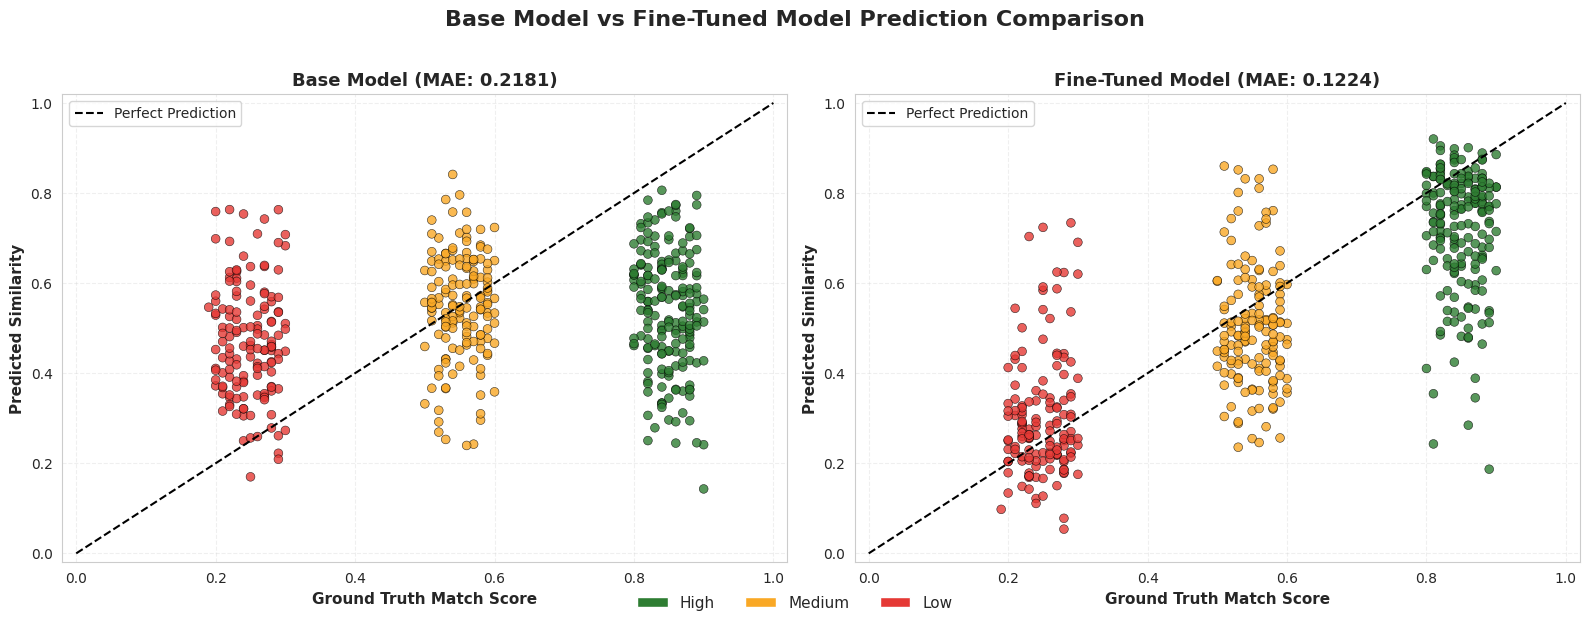

In [29]:
from matplotlib.patches import Patch

# -----------------------------------
# Color mapping for match labels
# -----------------------------------
color_map = {
    "low": "#E53935",      # Red
    "medium": "#F9A825",   # Orange
    "high": "#2E7D32"      # Green
}

colors = test_df["match_label"].str.lower().map(color_map)

# -----------------------------------
# Create side-by-side comparison plots
# -----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plots = [
    (axes[0], base_preds, "Base Model", base_mae),
    (axes[1], ft_preds, "Fine-Tuned Model", ft_mae)
]

for ax, preds, title, mae in plots:

    # Scatter plot
    ax.scatter(
        test_df["match_score"],
        preds,
        c=colors,
        s=40,
        edgecolors="black",
        linewidth=0.4,
        alpha=0.8
    )

    # Perfect prediction line
    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="black",
        linewidth=1.5,
        label="Perfect Prediction"
    )

    # Axis labels
    ax.set_xlabel(
        "Ground Truth Match Score",
        fontsize=11,
        fontweight="bold"
    )

    ax.set_ylabel(
        "Predicted Similarity",
        fontsize=11,
        fontweight="bold"
    )

    # Title
    ax.set_title(
        f"{title} (MAE: {mae:.4f})",
        fontsize=13,
        fontweight="bold"
    )

    # Same scale on both plots
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)

    # Grid
    ax.grid(True, linestyle="--", alpha=0.30)

    # Show legend for perfect prediction
    ax.legend(loc="upper left")

# -----------------------------------
# Common legend for match labels
# -----------------------------------
legend_elements = [
    Patch(facecolor=color_map["high"], label="High"),
    Patch(facecolor=color_map["medium"], label="Medium"),
    Patch(facecolor=color_map["low"], label="Low")
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=3,
    fontsize=11,
    frameon=False
)

# Overall title
fig.suptitle(
    "Base Model vs Fine-Tuned Model Prediction Comparison",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

# Adjust layout
plt.tight_layout()

plt.show()

# 💾 Save Model Metadata

In this step, we create a metadata dictionary containing the model configuration, dataset information, training settings, and evaluation results. The metadata is saved as a **JSON** file inside the fine-tuned model directory, making it easy to reproduce, document, and share the experiment in the future.

In [31]:
import json

# Store experiment metadata.
metadata = {

    # Model information.
    "Base Model": "all-mpnet-base-v2",

    # Dataset information.
    "Dataset": "merged_dataset_clean_pairs.csv",
    "Total Pairs": len(df),
    "Training Pairs": len(train_df),
    "Validation Pairs": len(val_df),
    "Test Pairs": len(test_df),

    # Training configuration.
    "Epochs": 15,
    "Batch Size": 16,

    # Evaluation results.
    "Base Model MAE": round(float(base_mae), 4),
    "Fine-Tuned Model MAE": round(float(ft_mae), 4),
    "MAE Improvement": round(float(base_mae - ft_mae), 4)
}

# Save the metadata as a JSON file.
with open("model2/finetuned-bert/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# Display a success message.
print("Metadata saved successfully!")
print("\nSaved Location: model2/finetuned-bert/metadata.json\n")

# Display the metadata.
print(json.dumps(metadata, indent=2))

Metadata saved successfully!

Saved Location: model2/finetuned-bert/metadata.json

{
  "Base Model": "all-mpnet-base-v2",
  "Dataset": "merged_dataset_clean_pairs.csv",
  "Total Pairs": 3221,
  "Training Pairs": 2254,
  "Validation Pairs": 483,
  "Test Pairs": 484,
  "Epochs": 15,
  "Batch Size": 16,
  "Base Model MAE": 0.2181,
  "Fine-Tuned Model MAE": 0.1224,
  "MAE Improvement": 0.0957
}


# 🚀 Test the Resume Matching Pipeline

In this step, we test the fine-tuned Sentence Transformer model with sample resume and job description pairs. The model generates embeddings, computes the cosine similarity score, and classifies the match as **High**, **Medium**, or **Low** based on predefined similarity thresholds. This simulates how the model would perform in a real-world resume screening application.

In [33]:
# Predict the similarity score between a resume and a job description.
def score_resume_against_jd(resume_text, jd_text):

    # Generate the resume embedding.
    emb_resume = finetuned_model.encode(
        resume_text,
        convert_to_numpy=True
    )

    # Generate the job description embedding.
    emb_jd = finetuned_model.encode(
        jd_text,
        convert_to_numpy=True
    )

    # Compute cosine similarity.
    score = cosine_similarity([emb_resume], [emb_jd])[0][0]

    return float(score)


# -----------------------------------------
# Sample test cases
# -----------------------------------------
test_cases = [

    {
        "expected": "HIGH",
        "resume": "Experienced Python developer with NLP, Machine Learning, PyTorch and FastAPI.",
        "jd": "Looking for a Python AI Engineer with experience in Machine Learning, NLP and FastAPI."
    },

    {
        "expected": "MEDIUM",
        "resume": "Frontend developer skilled in React, JavaScript and HTML.",
        "jd": "Hiring a Full Stack Developer with React and Node.js experience."
    },

    {
        "expected": "LOW",
        "resume": "Civil Engineer with AutoCAD and construction management experience.",
        "jd": "Hiring a Data Scientist with Python, Deep Learning and SQL."
    }

]

print("Production Pipeline Test")
print("=" * 60)

# Predict each test case.
for case in test_cases:

    score = score_resume_against_jd(
        case["resume"],
        case["jd"]
    )

    # Convert similarity score into a label.
    if score >= 0.70:
        label = "HIGH"
    elif score >= 0.50:
        label = "MEDIUM"
    else:
        label = "LOW"

    # Display the result.
    print(f"{case['expected']} match expected")
    print(f"    Predicted Score: {score:.4f}  →  {label}")
    print()

Production Pipeline Test
HIGH match expected
    Predicted Score: 0.8143  →  HIGH

MEDIUM match expected
    Predicted Score: 0.7700  →  HIGH

LOW match expected
    Predicted Score: 0.3848  →  LOW



In [34]:
import shutil

shutil.make_archive(
    "/kaggle/working/model2",   # ZIP file name
    "zip",                     # Format
    "/kaggle/working/model2"    # Folder to zip
)

print("✅ ZIP file created successfully!")

✅ ZIP file created successfully!
